# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [3]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

In [4]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

1. What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?

In [5]:
print("Target distribution (proportions):")
print(fraud["fraud"].value_counts(normalize=True))

print("\nTarget distribution (counts):")
print(fraud["fraud"].value_counts())

Target distribution (proportions):
fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64

Target distribution (counts):
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64


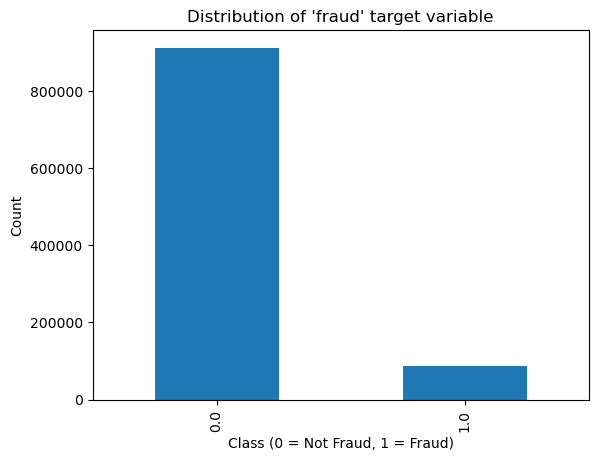

In [6]:
# Plot
fraud["fraud"].value_counts().plot(kind="bar")
plt.title("Distribution of 'fraud' target variable")
plt.xlabel("Class (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

•	91.26% of transactions are non-fraud ( 0 ) and 8.74% are fraud ( 1 ).
•	Since the fraud class is only ~8.7% of the data, therefore we are dealing with an imbalanced dataset.

2. Train a LogisticRegression.

In [7]:
X = fraud.drop(columns=["fraud"])
y = fraud["fraud"]

# Always split BEFORE any resampling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

# Baseline Logistic Regression (no class weights)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

3. Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.

In [9]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC (average precision):", average_precision_score(y_test, y_proba))

Confusion matrix:
 [[181293   1226]
 [  6917  10564]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.9632    0.9933    0.9780    182519
         1.0     0.8960    0.6043    0.7218     17481

    accuracy                         0.9593    200000
   macro avg     0.9296    0.7988    0.8499    200000
weighted avg     0.9574    0.9593    0.9556    200000

ROC-AUC: 0.9670393747290772
PR-AUC (average precision): 0.8069602491669982


- The model is good overall (high accuracy and ROC-AUC), but it still misses many fraud cases: it detects only ~60.4% of actual frauds (recall for class 1). 
- For fraud detection, this recall is relatively low; would be best if we could catch more fraudulent transactions even if it means more false alarms.

4. Run Oversample in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model?

In [10]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_os, y_train_os = ros.fit_resample(X_train, y_train)

print("Original train distribution:", Counter(y_train))
print("Oversampled train distribution:", Counter(y_train_os))

# Train Logistic Regression on oversampled data
log_reg_os = LogisticRegression(max_iter=1000)
log_reg_os.fit(X_train_os, y_train_os)

y_pred_os = log_reg_os.predict(X_test)
y_proba_os = log_reg_os.predict_proba(X_test)[:, 1]

print("\n=== Oversampling results ===")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_os))
print("\nClassification report:\n", classification_report(y_test, y_pred_os, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_os))
print("PR-AUC:", average_precision_score(y_test, y_proba_os))

Original train distribution: Counter({0.0: 730078, 1.0: 69922})
Oversampled train distribution: Counter({0.0: 730078, 1.0: 730078})

=== Oversampling results ===
Confusion matrix:
 [[170393  12126]
 [   910  16571]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.9947    0.9336    0.9632    182519
         1.0     0.5774    0.9479    0.7177     17481

    accuracy                         0.9348    200000
   macro avg     0.7861    0.9408    0.8404    200000
weighted avg     0.9582    0.9348    0.9417    200000

ROC-AUC: 0.979526855828483
PR-AUC: 0.7573730223360143


- Oversampling greatly increases fraud recall from 0.6043 → 0.9479: the model now catches most frauds.
- However, precision for fraud drops (more false positives: many non-fraud transactions flagged as fraud).

5. Now, run Undersample in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?

In [11]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

print("Original train distribution:", Counter(y_train))
print("Undersampled train distribution:", Counter(y_train_us))

log_reg_us = LogisticRegression(max_iter=1000)
log_reg_us.fit(X_train_us, y_train_us)

y_pred_us = log_reg_us.predict(X_test)
y_proba_us = log_reg_us.predict_proba(X_test)[:, 1]

print("\n=== Undersampling results ===")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_us))
print("\nClassification report:\n", classification_report(y_test, y_pred_us, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_us))
print("PR-AUC:", average_precision_score(y_test, y_proba_us))

Original train distribution: Counter({0.0: 730078, 1.0: 69922})
Undersampled train distribution: Counter({0.0: 69922, 1.0: 69922})

=== Undersampling results ===
Confusion matrix:
 [[170385  12134]
 [   917  16564]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.9946    0.9335    0.9631    182519
         1.0     0.5772    0.9475    0.7174     17481

    accuracy                         0.9347    200000
   macro avg     0.7859    0.9405    0.8402    200000
weighted avg     0.9582    0.9347    0.9416    200000

ROC-AUC: 0.9795777201660361
PR-AUC: 0.7564716050766447


Performance is very similar to oversampling:
- Fraud recall ~ 0.9475 (vs 0.9479 with oversampling)
- Precision ~ 0.5772

6. Finally, run SMOTE in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Original train distribution:", Counter(y_train))
print("SMOTE train distribution:", Counter(y_train_sm))

log_reg_sm = LogisticRegression(max_iter=1000)
log_reg_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = log_reg_sm.predict(X_test)
y_proba_sm = log_reg_sm.predict_proba(X_test)[:, 1]

print("\n=== SMOTE results ===")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_sm))
print("\nClassification report:\n", classification_report(y_test, y_pred_sm, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_sm))
print("PR-AUC:", average_precision_score(y_test, y_proba_sm))


Original train distribution: Counter({0.0: 730078, 1.0: 69922})
SMOTE train distribution: Counter({0.0: 730078, 1.0: 730078})

=== SMOTE results ===
Confusion matrix:
 [[170497  12022]
 [   942  16539]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.9945    0.9341    0.9634    182519
         1.0     0.5791    0.9461    0.7184     17481

    accuracy                         0.9352    200000
   macro avg     0.7868    0.9401    0.8409    200000
weighted avg     0.9582    0.9352    0.9420    200000

ROC-AUC: 0.9791807624812945
PR-AUC: 0.7616496369799658


SMOTE gives a very similar performance to random over/undersampling:
- Fraud recall ~ 0.9461
- Precision ~ 0.5791

Overall: Resampling the training data (by oversampling, undersampling, or SMOTE) substantially improves the model’s ability to detect fraudulent transactions, increasing recall from ~60% to ~95%. The trade-off is lower precision, meaning more non-fraud transactions are incorrectly flagged. 